In [2]:
import yfinance as yf
import pandas as pd

data =  yf.download("INTC", period="5y")

data = data[["Close"]]
print(data)


[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           INTC
Date                 
2020-03-04  52.016056
2020-03-05  50.491379
2020-03-06  49.436531
2020-03-09  45.075260
2020-03-10  47.849800
...               ...
2025-02-26  23.520000
2025-02-27  23.090000
2025-02-28  23.730000
2025-03-03  22.740000
2025-03-04  21.879999

[1257 rows x 1 columns]


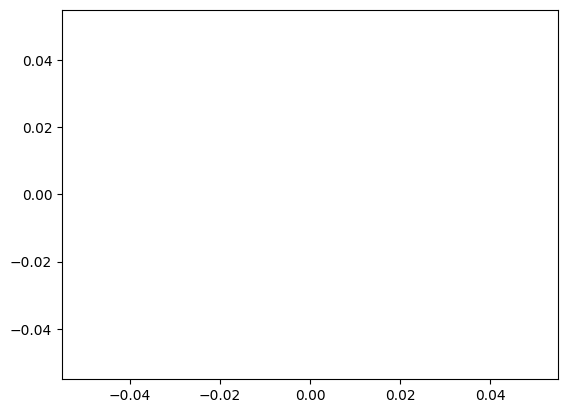

In [6]:
import matplotlib.pyplot as plt

plt.plot(data.index, data["Adj Close"])

In [10]:
import numpy as np
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)


def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=5):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date
  
    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)
    
        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        values = df_subset['Adj Close'].to_numpy()
        x, y = values[:-1], values[-1]

        dates.append(target_date)
        X.append(x)
        Y.append(y)

        next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
        next_date_str = next_datetime_str.split('T')[0]
        year_month_day = next_date_str.split('-')
        year, month, day = year_month_day
        next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
    
        if last_time:
            break
    
        target_date = next_date

        if target_date == last_date:
            last_time = True
    
    ret_df = pd.DataFrame({})
    ret_df['Target Date'] = dates
  
    X = np.array(X)
    for i in range(0, n):
        X[:, i]
        ret_df[f'Target-{n-i}'] = X[:, i]
  
    ret_df['Target'] = Y

    return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(data, 
                            '2020-11-09', 
                            '2024-12-18', 
                            n=5)
windowed_df

Error: Window of size 5 is too large for date 2020-11-09 00:00:00


In [8]:
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()

    dates = df_as_np[:, 0]

    middle_matrix = df_as_np[:, 1:-1]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

    Y = df_as_np[:, -1]

    return dates, X.astype(np.float64), Y.astype(np.float64)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

AttributeError: 'NoneType' object has no attribute 'to_numpy'

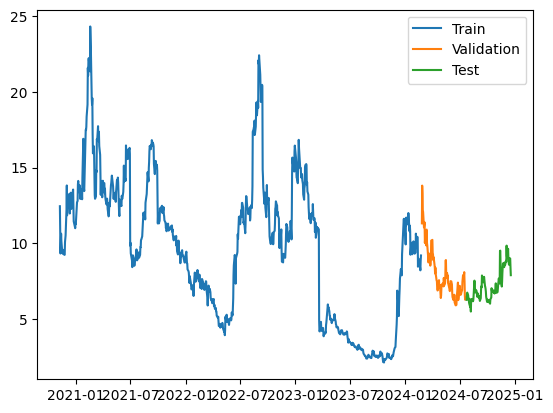

In [ ]:
q_80 = int(len(dates) * 0.8)
q_90 = int(len(dates) * 0.9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((5, 1)), 
                                 layers.LSTM(64),
                                 layers.Dense(32, activation="relu"),
                                 layers.Dense(32, activation="relu"),
                                 layers.Dense(1)])

model.compile(loss="mse", 
              optimizer=Adam(learning_rate=0.001),
              metrics=["mean_absolute_error"])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 98.3800 - mean_absolute_error: 8.7522 - val_loss: 13.4186 - val_mean_absolute_error: 3.3072
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31.4526 - mean_absolute_error: 4.4201 - val_loss: 10.8869 - val_mean_absolute_error: 3.1192
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2593 - mean_absolute_error: 2.0321 - val_loss: 1.6492 - val_mean_absolute_error: 1.1577
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9548 - mean_absolute_error: 0.8619 - val_loss: 0.5016 - val_mean_absolute_error: 0.4953
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8755 - mean_absolute_error: 0.5875 - val_loss: 0.4621 - val_mean_absolute_error: 0.4997
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8152 - mean_absolute_error: 0.5320 - val_loss: 0.4290 - val_mean_absolute_error: 0.4747
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5721 - mean_absolute_error: 0.4958 - val_

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


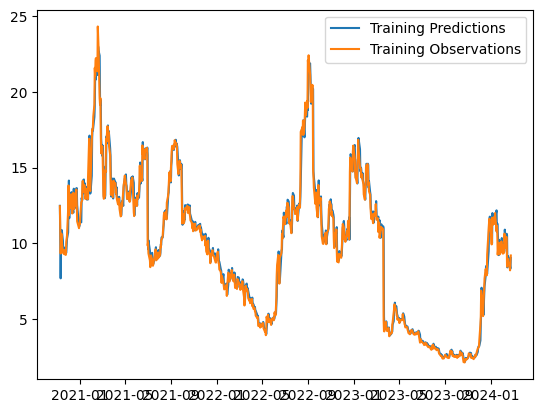

In [ ]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step


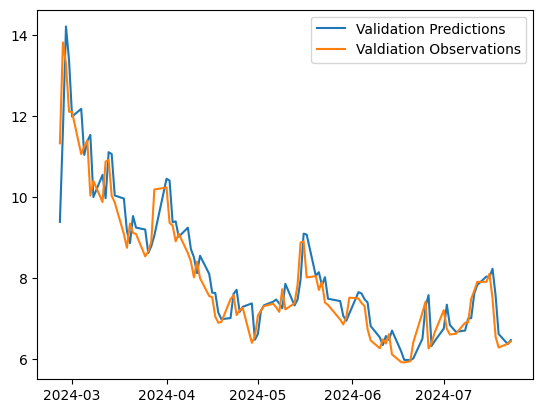

In [ ]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Valdiation Observations"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step


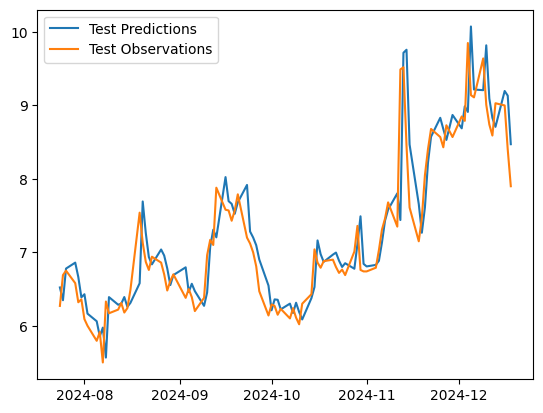

In [ ]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Test Predictions", "Test Observations"])

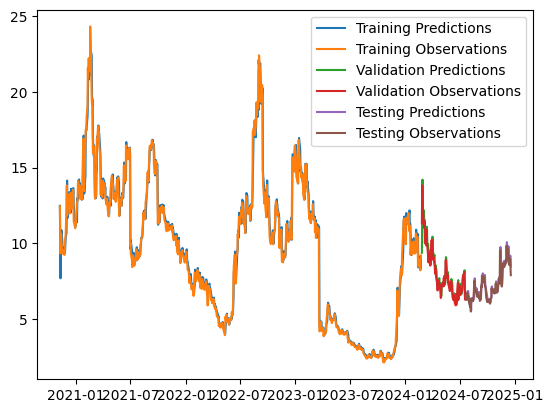

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)

plt.legend([
    "Training Predictions",
    "Training Observations",
    "Validation Predictions",
    "Validation Observations",
    "Testing Predictions",
    "Testing Observations"
])

In [ ]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━

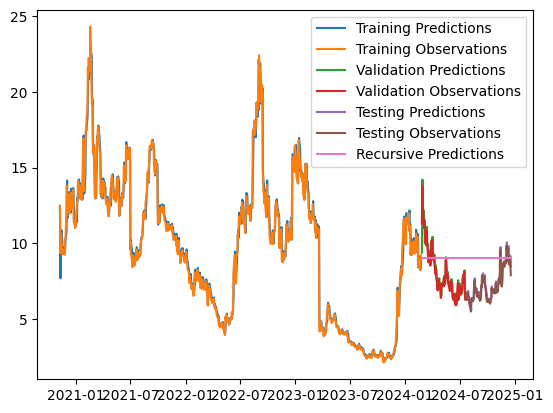

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)

plt.plot(recursive_dates, recursive_predictions)

plt.legend([
    "Training Predictions",
    "Training Observations",
    "Validation Predictions",
    "Validation Observations",
    "Testing Predictions",
    "Testing Observations",
    "Recursive Predictions"
])

In [ ]:
input_data = np.array([6.22, 6.09, 6.03, 6.99, 7.24]).reshape(1, 5, 1)

prediction = model.predict(input_data)
print(prediction)

input_data = np.array([6.03, 6.99, 7.24, 7.66, 7.39]).reshape(1, 5, 1)
prediction = model.predict(input_data)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[7.40505]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[7.4900627]]


In [ ]:
right_direction = 0
difference_avg = 0

for i in range(1, len(test_predictions)):
    predicted_percent_change = ((y_test[i - 1] - test_predictions[i])/y_test[i-1]).round(4)
    observed_percent_change = ((y_test[i - 1] - y_test[i])/y_test[i-1]).round(4)
    difference = (observed_percent_change - predicted_percent_change).round(4)
    print(f"{dates_test[i]}: Observation = {observed_percent_change} || Predicted = {predicted_percent_change} || Difference = {difference}")

    sign = predicted_percent_change * observed_percent_change
    if(sign > 0 or (difference < 0.01 and difference > -0.01)):
        right_direction += 1
    difference_avg += abs(difference)

2024-07-25 00:00:00: Observation = -0.067 || Predicted = -0.0124 || Difference = -0.0546
2024-07-26 00:00:00: Observation = -0.009 || Predicted = -0.0133 || Difference = 0.0043
2024-07-29 00:00:00: Observation = 0.0252 || Predicted = -0.0162 || Difference = 0.0414
2024-07-30 00:00:00: Observation = 0.0395 || Predicted = -0.0127 || Difference = 0.0522
2024-07-31 00:00:00: Observation = -0.0063 || Predicted = -0.0106 || Difference = 0.0043
2024-08-01 00:00:00: Observation = 0.0425 || Predicted = -0.0109 || Difference = 0.0534
2024-08-02 00:00:00: Observation = 0.0148 || Predicted = -0.0123 || Difference = 0.0271
2024-08-05 00:00:00: Observation = 0.0342 || Predicted = -0.0103 || Difference = 0.0445
2024-08-06 00:00:00: Observation = -0.0207 || Predicted = -0.0107 || Difference = -0.01
2024-08-07 00:00:00: Observation = 0.0702 || Predicted = -0.0101 || Difference = 0.0803
2024-08-08 00:00:00: Observation = -0.1509 || Predicted = -0.0121 || Difference = -0.1388
2024-08-09 00:00:00: Observa

In [ ]:
print(right_direction/len(test_predictions))
print(difference_avg/len(test_predictions))

0.4519230769230769
0.03988557692307692


In [ ]:
p_and_l = 0
curr_stock = 0
price_of_trade = []

for i in range(0, len(test_predictions) - 1):
    next_day_prediction = (test_predictions[i+1]).round(2)
    curr_day_price = y_test[i].round(2)

    # print(f"Next Day Prediction: {next_day_prediction} || Current Price: {curr_day_price}")

    if(next_day_prediction > curr_day_price):

        if(curr_stock < 0):
            for price in price_of_trade:
                p_and_l += price - curr_day_price
            curr_stock = 0
            price_of_trade = []

        curr_stock += 1
        price_of_trade.append(curr_day_price)

    elif(next_day_prediction < curr_day_price):

        if(curr_stock > 0):
            for price in price_of_trade:
                p_and_l += curr_day_price - price
            curr_stock = 0
            price_of_trade = []

        curr_stock -= 1
        price_of_trade.append(curr_day_price)

print(f"Profit and Loss: {p_and_l}")
print(f"Current Portfolio: {curr_stock} @ {price_of_trade}\n")

print("Close out Portfolio")
if(curr_stock > 0):
    for price in price_of_trade:
        p_and_l += curr_day_price - price
else:
    for price in price_of_trade:
        p_and_l += price - curr_day_price

print(f"Closed out Portfolio Profit and Loss: {p_and_l}")

Profit and Loss: 0
Current Portfolio: 103 @ [6.27, 6.69, 6.75, 6.58, 6.32, 6.36, 6.09, 6.0, 5.8, 5.91, 5.5, 6.33, 6.17, 6.22, 6.31, 6.18, 6.24, 6.49, 7.54, 7.13, 6.87, 6.76, 6.94, 6.86, 6.7, 6.48, 6.61, 6.7, 6.38, 6.5, 6.39, 6.2, 6.38, 6.96, 7.17, 7.1, 7.88, 7.58, 7.57, 7.43, 7.57, 7.79, 7.2, 7.12, 7.0, 6.81, 6.47, 6.14, 6.29, 6.27, 6.15, 6.23, 6.1, 6.24, 6.11, 6.02, 6.3, 6.43, 7.04, 6.86, 6.79, 6.88, 6.9, 6.8, 6.72, 6.76, 6.69, 7.01, 7.36, 6.76, 6.74, 6.74, 6.79, 7.03, 7.31, 7.46, 7.68, 7.35, 9.49, 9.52, 8.45, 7.61, 7.15, 7.47, 8.05, 8.4, 8.68, 8.57, 8.43, 8.73, 8.57, 8.85, 8.79, 9.85, 9.14, 9.11, 9.64, 9.01, 8.74, 8.59, 9.03, 9.0, 8.4]

Close out Portfolio
Closed out Portfolio Profit and Loss: 125.68000000000002


In [ ]:
p_and_l = 0
curr_stock = 0
price_of_trade = []

for i in range(0, len(val_predictions) - 1):
    next_day_prediction = (val_predictions[i+1]).round(2)
    curr_day_price = y_val[i].round(2)

    # print(f"Next Day Prediction: {next_day_prediction} || Current Price: {curr_day_price}")

    if(next_day_prediction > curr_day_price):

        if(curr_stock < 0):
            for price in price_of_trade:
                p_and_l += price - curr_day_price
            curr_stock = 0
            price_of_trade = []

        curr_stock += 1
        price_of_trade.append(curr_day_price)

    elif(next_day_prediction < curr_day_price):

        if(curr_stock > 0):
            for price in price_of_trade:
                p_and_l += curr_day_price - price
            curr_stock = 0
            price_of_trade = []

        curr_stock -= 1
        price_of_trade.append(curr_day_price)

print(f"Profit and Loss: {p_and_l}")
print(f"Current Portfolio: {curr_stock} @ {price_of_trade}\n")

print("Close out Portfolio")
if(curr_stock > 0):
    for price in price_of_trade:
        p_and_l += curr_day_price - price
else:
    for price in price_of_trade:
        p_and_l += price - curr_day_price

print(f"Closed out Portfolio Profit and Loss: {p_and_l}")

Profit and Loss: -6.260000000000003
Current Portfolio: 93 @ [10.39, 9.87, 10.87, 10.91, 10.02, 9.86, 9.08, 8.74, 9.34, 9.11, 9.08, 8.53, 8.65, 8.89, 10.18, 10.23, 9.35, 9.29, 8.9, 9.09, 8.61, 8.4, 8.01, 8.4, 7.99, 7.55, 7.52, 7.04, 6.89, 6.91, 7.47, 7.57, 7.08, 7.2, 7.26, 6.39, 6.55, 7.07, 7.19, 7.3, 7.36, 7.27, 7.16, 7.72, 7.22, 7.37, 7.82, 8.87, 8.9, 8.01, 8.04, 7.7, 7.89, 7.39, 7.33, 6.97, 6.85, 7.02, 7.51, 7.49, 7.38, 7.3, 6.73, 6.45, 6.26, 6.48, 6.38, 6.61, 6.11, 5.92, 5.91, 5.94, 6.41, 7.14, 7.41, 6.26, 6.39, 6.65, 7.2, 6.74, 6.6, 6.62, 6.89, 6.9, 7.48, 7.68, 7.9, 7.9, 8.1, 7.49, 6.55, 6.28, 6.37]

Close out Portfolio
Closed out Portfolio Profit and Loss: -128.95000000000005
